In [1]:

import os
import tensorflow as tf
import tensorflow_datasets as tfds
import keras
from keras import layers
# from keras.preprocessing.image import ImageDataGenerator


2026-02-12 02:45:29.321209: I tensorflow/core/platform/cpu_feature_guard.cc:183] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
devices=tf.config.experimental.list_physical_devices()
devices

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'),
 PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [4]:
IMG_SIZE = 128   # or whatever you trained with
BATCH_SIZE=32
train_ds, val_ds = tfds.load(
    "citrus_leaves",
    split=["train[:80%]", "train[80%:]"],
    as_supervised=True,
    data_dir="/app/data/tfds"
)
len(train_ds)


2026-02-11 09:52:41.852646: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1636] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 211 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:d8:00.0, compute capability: 6.0


475

In [5]:
ds_info = tfds.builder("citrus_leaves", data_dir="/app/data/tfds").info
class_names = ds_info.features["label"].names
print(class_names)

['Black spot', 'canker', 'greening', 'healthy']


In [6]:
def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32)          # convert uint8 → float32
    # image = image / 255.0                   # normalize to [0,1]
    return image, label


In [7]:
train_ds_transformed = (
    train_ds
    .map(preprocess)
    .cache()
    .shuffle(1000)   # shuffle examples
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds_transformed = (
    val_ds
    .map(preprocess)
    .cache()
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)


In [8]:

from matplotlib import pyplot as plt


def visualize_dataset(dataset, num_images=9):
    plt.figure(figsize=(8, 8))
    count = 0
    dataset_iter = dataset.unbatch().as_numpy_iterator()
    for image, label in dataset_iter:
        if image.dtype != "float32":
            image = image.astype("float32") / 255.0
        image = image.astype("float32") / 255.0

        plt.subplot(3, 3, count + 1)
        plt.imshow(image)
        plt.title(f"Label: {label}")
        plt.axis("off")
        count += 1
        if count >= num_images:
            break

    plt.show()


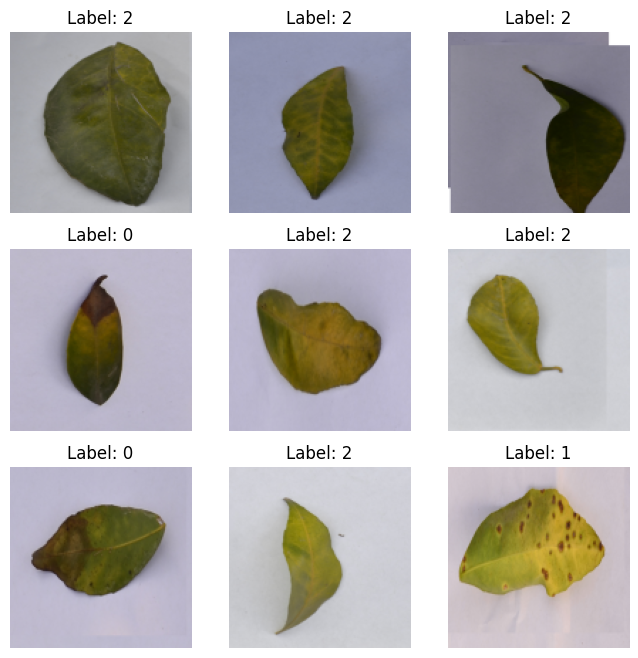

In [9]:

# Visualize
visualize_dataset(train_ds_transformed)



In [10]:
import keras

from keras import regularizers
reg = regularizers.l2(1e-4)

data_augmentation = keras.Sequential([
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomRotation(0.2),
    keras.layers.RandomZoom(0.2),
    keras.layers.RandomContrast(0.2),
    keras.layers.RandomTranslation(0.1, 0.1),
])


In [11]:
base = tf.keras.applications.EfficientNetV2B0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base.trainable = False 

In [12]:
model = keras.Sequential([
    keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    data_augmentation,  

    keras.layers.Lambda(
        tf.keras.applications.efficientnet.preprocess_input
    ),

    base,

    keras.layers.GlobalAveragePooling2D(),
    keras.layers.BatchNormalization(),

    keras.layers.Dense(128, activation="relu"),
    # keras.layers.Dropout(0.5),

    keras.layers.Dense(4, activation="softmax"),
])


In [13]:

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss='sparse_categorical_crossentropy', metrics=['accuracy']
)


In [14]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential (Sequential)     (None, 128, 128, 3)       0         
                                                                 
 lambda (Lambda)             (None, 128, 128, 3)       0         
                                                                 
 efficientnetv2-b0 (Functio  (None, 4, 4, 1280)        5919312   
 nal)                                                            
                                                                 
 global_average_pooling2d (  (None, 1280)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 batch_normalization (Batch  (None, 1280)              5120      
 Normalization)                                                  
                                                      

In [15]:
class myCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs={}):
        if (logs.get('accuracy') > 0.90 and logs.get('val_accuracy') > 0.90):
            if self.model:
                self.model.stop_training = True
            print("\n\nSufficient Metrics Reached!\n\n")


In [16]:
epochs=100
history=model.fit(
    train_ds_transformed,
    epochs=epochs,
    # batch_size=BATCH_SIZE,
    validation_data=val_ds_transformed,
    callbacks=myCallback()
    
)


Epoch 1/100


2026-02-11 09:52:54.900740: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:1014] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape insequential_1/efficientnetv2-b0/block2b_drop/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
2026-02-11 09:52:55.665682: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:432] Loaded cuDNN version 8905
2026-02-11 09:52:55.870548: W tensorflow/tsl/framework/bfc_allocator.cc:296] Allocator (GPU_0_bfc) ran out of memory trying to allocate 144.00MiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-02-11 09:52:55.870638: W tensorflow/tsl/framework/bfc_allocator.cc:296] Allocator (GPU_0_bfc) ran out of memory trying to allocate 144.00MiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more mem

 3/15 [=====>........................] - ETA: 1s - loss: 1.8048 - accuracy: 0.3958

2026-02-11 09:52:57.016542: W tensorflow/tsl/framework/bfc_allocator.cc:296] Allocator (GPU_0_bfc) ran out of memory trying to allocate 144.00MiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-02-11 09:52:57.016617: W tensorflow/tsl/framework/bfc_allocator.cc:296] Allocator (GPU_0_bfc) ran out of memory trying to allocate 144.00MiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-02-11 09:52:57.016647: W tensorflow/tsl/framework/bfc_allocator.cc:296] Allocator (GPU_0_bfc) ran out of memory trying to allocate 195.02MiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-02-11 09:52:57.127431: W tensorflow/tsl/framework/bfc_allocator.cc:296] Allocato

15/15 [==============================] - 13s 210ms/step - loss: 1.1791 - accuracy: 0.5747 - val_loss: 0.8381 - val_accuracy: 0.7479
Epoch 2/100
15/15 [==============================] - 1s 44ms/step - loss: 0.5917 - accuracy: 0.7937 - val_loss: 0.7024 - val_accuracy: 0.7815
Epoch 3/100
15/15 [==============================] - 1s 39ms/step - loss: 0.4083 - accuracy: 0.8526 - val_loss: 0.6067 - val_accuracy: 0.8067
Epoch 4/100
15/15 [==============================] - 1s 35ms/step - loss: 0.3823 - accuracy: 0.8611 - val_loss: 0.5350 - val_accuracy: 0.8655
Epoch 5/100
15/15 [==============================] - 1s 39ms/step - loss: 0.3273 - accuracy: 0.8758 - val_loss: 0.4747 - val_accuracy: 0.8739
Epoch 6/100
15/15 [==============================] - 1s 37ms/step - loss: 0.2727 - accuracy: 0.9053 - val_loss: 0.4675 - val_accuracy: 0.8655
Epoch 7/100
15/15 [==============================] - 1s 37ms/step - loss: 0.2674 - accuracy: 0.9095 - val_loss: 0.4532 - val_accuracy: 0.8403
Epoch 8/100
15/1

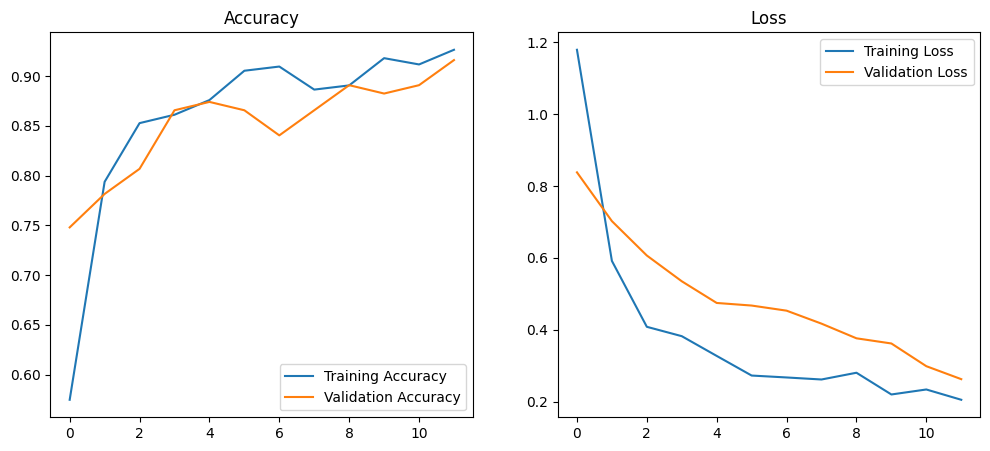

In [17]:
import matplotlib.pyplot as plt

acc      = history.history['accuracy']
val_acc  = history.history['val_accuracy']
loss     = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(epochs_range, acc, label="Training Accuracy")
plt.plot(epochs_range, val_acc, label="Validation Accuracy")
plt.legend(loc="lower right")
plt.title("Accuracy")

# Loss
plt.subplot(1,2,2)
plt.plot(epochs_range, loss, label="Training Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.legend(loc="upper right")
plt.title("Loss")

plt.show()


In [19]:
model.save("citrus_efficientnet.h5")